<a href="https://colab.research.google.com/github/sk27110/MMK/blob/HW2/HW2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Тут другой датасет, код полностью аналоничен прошлому, выводы в целом тоже ровно такие же.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.utils import resample
from tqdm import tqdm

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease-dataset' dataset.
Path to dataset files: /kaggle/input/heart-disease-dataset


In [3]:
data = pd.read_csv(path + "/heart.csv")

In [4]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
data.isna().sum().sum()

np.int64(0)

In [9]:
X = data.drop("target", axis=1)
y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "NaiveBayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

report_dict = {}
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)

    results[name] = acc

    report = classification_report(y_test, y_pred, output_dict=True)
    report_dict[name] = report

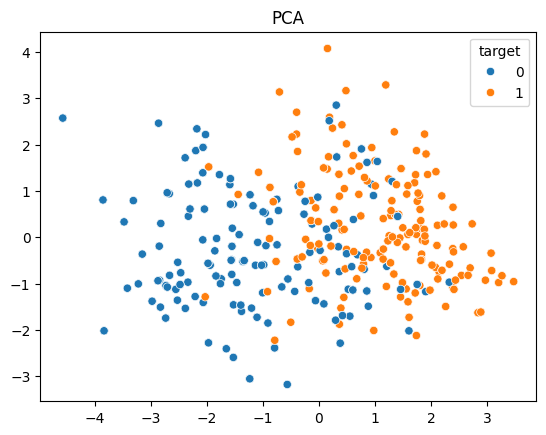

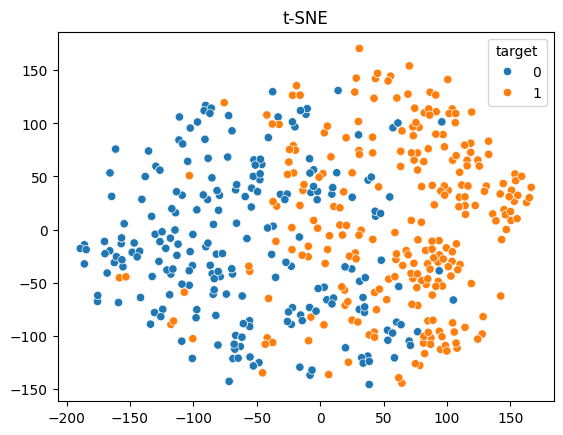

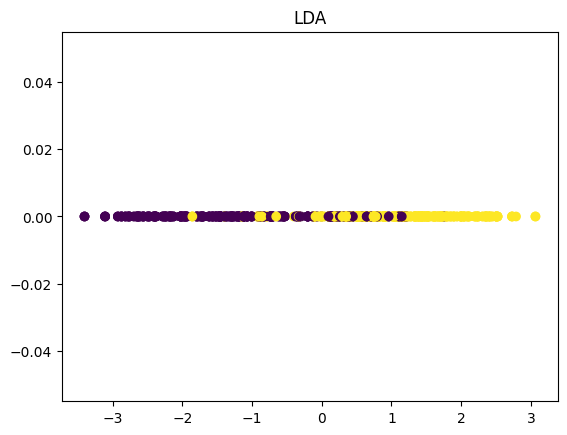

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)
plt.figure()
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_train)
plt.title("PCA")
plt.show()


tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_train_scaled)
plt.figure()
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_train)
plt.title("t-SNE")
plt.show()


lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_train_scaled, y_train)
plt.figure()
plt.scatter(X_lda, np.zeros_like(X_lda), c=y_train)
plt.title("LDA")
plt.show()

In [13]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


lda = LinearDiscriminantAnalysis(n_components=1)

X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

In [15]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "RandomForest": RandomForestClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "NaiveBayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

def bootstrap_evaluation(model, X, y, iterations=250):

    scores = []

    for _ in tqdm(range(iterations)):

        X_sample, y_sample = resample(X, y)

        X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
            X_sample, y_sample, test_size=0.2
        )

        model.fit(X_train_b, y_train_b)

        y_pred = model.predict(X_test_b)

        acc = accuracy_score(y_test_b, y_pred)

        scores.append(acc)

    return np.mean(scores), np.std(scores)

In [16]:
datasets = {
    "Original": (X_train_scaled, y_train),
    "PCA": (X_train_pca, y_train),
    "LDA": (X_train_lda, y_train)
}

In [17]:
import pandas as pd

results_bootstrap = []

for dataset_name, (X_data, y_data) in datasets.items():

    for model_name, model in models.items():

        mean_acc, std_acc = bootstrap_evaluation(
            model, X_data, y_data, iterations=250
        )

        results_bootstrap.append({
            "Dataset": dataset_name,
            "Model": model_name,
            "Bootstrap Mean Accuracy": mean_acc,
            "Bootstrap Std": std_acc
        })

        print(dataset_name, model_name, mean_acc, std_acc)

100%|██████████| 250/250 [00:01<00:00, 145.88it/s]


Original LogisticRegression 0.8415365853658536 0.03138429264941468


100%|██████████| 250/250 [00:04<00:00, 59.56it/s]


Original SVM 0.9216829268292682 0.022967387581655774


100%|██████████| 250/250 [00:58<00:00,  4.28it/s]


...

LDA GradientBoosting 0.9500975609756097 0.01906318745651888


100%|██████████| 250/250 [00:00<00:00, 319.36it/s]


LDA NaiveBayes 0.8388292682926829 0.032064925212938855


100%|██████████| 250/250 [00:01<00:00, 158.34it/s]

LDA KNN 0.9064634146341464 0.026494867225409686


In [18]:
results_df = pd.DataFrame(results_bootstrap)
print(results_df)

     Dataset               Model  Bootstrap Mean Accuracy  Bootstrap Std
0   Original  LogisticRegression                 0.841537       0.031384
1   Original                 SVM                 0.921683       0.022967
2   Original        RandomForest                 0.977902       0.014204
3   Original    GradientBoosting                 0.965366       0.016400
4   Original          NaiveBayes                 0.827171       0.031340
5   Original                 KNN                 0.894610       0.025179
6        PCA  LogisticRegression                 0.801561       0.031806
7        PCA                 SVM                 0.816683       0.031948
8        PCA        RandomForest                 0.968561       0.014901
9        PCA    GradientBoosting                 0.935537       0.020110
10       PCA          NaiveBayes                 0.800854       0.033474
11       PCA                 KNN                 0.862610       0.029315
12       LDA  LogisticRegression                 0.

In [19]:
acc_df = pd.DataFrame(
    list(results.items()),
    columns=["Model", "Test Accuracy"]
)

orig = results_df[results_df["Dataset"] == "Original"]
pca = results_df[results_df["Dataset"] == "PCA"]
lda = results_df[results_df["Dataset"] == "LDA"]

orig = orig[["Model", "Bootstrap Mean Accuracy", "Bootstrap Std"]]
orig.columns = ["Model", "Mean Original", "Std Original"]

pca = pca[["Model", "Bootstrap Mean Accuracy", "Bootstrap Std"]]
pca.columns = ["Model", "Mean PCA", "Std PCA"]

lda = lda[["Model", "Bootstrap Mean Accuracy", "Bootstrap Std"]]
lda.columns = ["Model", "Mean LDA", "Std LDA"]

final_df = acc_df.merge(orig, on="Model")
final_df = final_df.merge(pca, on="Model")
final_df = final_df.merge(lda, on="Model")

In [20]:
param_dist = {
    "C": np.logspace(-3, 3, 50),
    "gamma": ["scale", "auto"],
    "kernel": ["rbf", "linear", "poly"]
}

svm = SVC(probability=True)

random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

best_svm = random_search.best_estimator_

print(random_search.best_params_)
print(random_search.best_score_)

{'kernel': 'poly', 'gamma': 'scale', 'C': np.float64(244.205309454865)}
0.9817073170731707


In [21]:
y_pred_svm = best_svm.predict(X_test_scaled)
print(classification_report(y_test, y_pred_svm))

test_acc_svm = accuracy_score(y_test, y_pred_svm)
print(test_acc_svm)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205

1.0


### Отчет

In [26]:
for name, report in report_dict.items():
    print("\n", "="*40)
    print(f"{name} Classification Report")
    print("="*40)
    report_text = classification_report(y_test, models[name].predict(X_test_scaled))
    print(report_text)


LogisticRegression Classification Report
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       100
           1       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205


SVM Classification Report
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       100
           1       0.92      0.94      0.93       105

    accuracy                           0.93       205
   macro avg       0.93      0.93      0.93       205
weighted avg       0.93      0.93      0.93       205


RandomForest Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00

In [23]:
final_df

,Model,Test Accuracy,Mean Original,Std Original,Mean PCA,Std PCA,Mean LDA,Std LDA
0,LogisticRegression,0.809756,0.841537,0.031384,0.801561,0.031806,0.839073,0.026375
1,SVM,0.926829,0.921683,0.022967,0.816683,0.031948,0.838000,0.030700
2,RandomForest,1.000000,0.977902,0.014204,0.968561,0.014901,0.978829,0.012450
3,GradientBoosting,0.975610,0.965366,0.016400,0.935537,0.020110,0.950098,0.019063
4,NaiveBayes,0.829268,0.827171,0.031340,0.800854,0.033474,0.838829,0.032065
5,KNN,0.863415,0.894610,0.025179,0.862610,0.029315,0.906463,0.026495


In [24]:
print("Лучшие параметры:", random_search.best_params_)
print("Лучший результат:", random_search.best_score_)
print("Результат на тесте:", test_acc_svm)

Лучшие параметры: {'kernel': 'poly', 'gamma': 'scale', 'C': np.float64(244.205309454865)}
Лучший результат: 0.9817073170731707
Результат на тесте: 1.0


### Выводы

Лучшей моделькой без бутстреппинга оказался RandomForest, на тесте он сделал идеальное предсказание. Такой же результат дала SVM с подобранными параметрами.

При бутстреппинге лучшими также оказались RandomForest и GradientBoosting.
Методы PCA и LDA выдали ровно такой же результат, как и для прошлого датасета.